In [1]:
import sys, os
os.chdir('..')
sys.path.insert(0, '.')

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import joblib

os.makedirs('models', exist_ok=True)
os.makedirs('results', exist_ok=True)

print("All imports successful")

All imports successful


In [2]:
from datasets import load_dataset

print("Streaming dataset")

dataset = load_dataset(
    "McAuley-Lab/Amazon-Reviews-2023",
    "raw_review_Electronics",
    trust_remote_code=True,
    streaming=True
)

records = []
for i, row in enumerate(dataset['full']):
    if i >= 50000:
        break
    records.append({'text': row['text'], 'rating': row['rating']})

df = pd.DataFrame(records).dropna()
print(f"Dataset shape: {df.shape}")
print(df['rating'].value_counts().sort_index())

d:\Project 2\.venv1\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Streaming dataset
Dataset shape: (50000, 2)
rating
1.0     4144
2.0     2117
3.0     3412
4.0     7383
5.0    32944
Name: count, dtype: int64


In [3]:
def rating_to_label(rating):
    if rating <= 2:
        return 'negative'
    elif rating == 3:
        return 'neutral'
    else:
        return 'positive'

df['label'] = df['rating'].apply(rating_to_label)

print("Label distribution:")
print(df['label'].value_counts())
print(f"\nTotal reviews: {len(df)}")

Label distribution:
label
positive    40327
negative     6261
neutral      3412
Name: count, dtype: int64

Total reviews: 50000


In [4]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'<.*?>', '', text)   # remove HTML tags
    text = re.sub(r'\s+', ' ', text)    # collapse whitespace
    return text.strip()

df['clean_text'] = df['text'].apply(clean_text)

# Verify it works
print("Before:", df['text'].iloc[0][:100])
print("After: ", df['clean_text'].iloc[0][:100])

Before: First & most offensive: they reek of gasoline so if you are sensitive/allergic to petroleum products
After:  first & most offensive: they reek of gasoline so if you are sensitive/allergic to petroleum products


In [5]:
X = df['clean_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y       # preserves label proportions in both splits
)

print(f"Training samples: {len(X_train)}")
print(f"Test samples:     {len(X_test)}")
print(f"\nTrain label distribution:\n{y_train.value_counts()}")

Training samples: 40000
Test samples:     10000

Train label distribution:
label
positive    32262
negative     5009
neutral      2729
Name: count, dtype: int64


In [6]:
# Theory note:
# TfidfVectorizer converts text to numbers.
# ngram_range=(1,2) means it captures single words AND word pairs
# e.g. "not good" is captured as a pair — important for sentiment!
# class_weight='balanced' handles the fact that 5-star reviews dominate

baseline_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=10000,
        ngram_range=(1, 2),
        stop_words='english'
    )),
    ('clf', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ))
])

baseline_pipeline.fit(X_train, y_train)
print("Trained baseline model")

Trained baseline model


In [7]:
y_pred_baseline = baseline_pipeline.predict(X_test)

print("Baseline: TF-IDF + Logistic Regression")
print(classification_report(y_test, y_pred_baseline))

# Save results for README
baseline_report = classification_report(y_test, y_pred_baseline, output_dict=True)
baseline_f1 = baseline_report['macro avg']['f1-score']
print(f"Macro F1: {baseline_f1:.4f}")

Baseline: TF-IDF + Logistic Regression
              precision    recall  f1-score   support

    negative       0.57      0.70      0.63      1252
     neutral       0.21      0.43      0.28       683
    positive       0.96      0.84      0.89      8065

    accuracy                           0.79     10000
   macro avg       0.58      0.66      0.60     10000
weighted avg       0.86      0.79      0.82     10000

Macro F1: 0.6004


In [8]:
joblib.dump(baseline_pipeline, 'models/baseline_model.pkl')
print("Baseline model saved to models/baseline_model.pkl")

Baseline model saved to models/baseline_model.pkl


In [9]:
from sentence_transformers import SentenceTransformer

embedder = SentenceTransformer('all-MiniLM-L6-v2')

print("Encoding training data")
X_train_emb = embedder.encode(
    X_train.tolist(),
    batch_size=64,
    show_progress_bar=True
)

print("Encoding test data")
X_test_emb = embedder.encode(
    X_test.tolist(),
    batch_size=64,
    show_progress_bar=True
)

# Save so you never have to re-run this
np.save('models/X_train_emb.npy', X_train_emb)
np.save('models/X_test_emb.npy', X_test_emb)

# Save labels too — needed if you reload embeddings later
y_train.to_csv('models/y_train.csv', index=False)
y_test.to_csv('models/y_test.csv', index=False)

print(f"Embeddings shape: {X_train_emb.shape}")
print("Embeddings saved")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 5261.72it/s]


Encoding training data


Batches: 100%|██████████| 625/625 [00:24<00:00, 25.63it/s] 


Encoding test data


Batches: 100%|██████████| 157/157 [00:06<00:00, 25.48it/s]


Embeddings shape: (40000, 384)
Embeddings saved


In [ ]:
from xgboost import XGBClassifier
import numpy as np

# Encode string labels to numbers — XGBoost requires numeric targets
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)

print("Label encoding:", dict(zip(le.classes_, le.transform(le.classes_))))

# Compute per-sample weights so every class contributes equally to the loss, exactly like class_weight='balanced' does for sklearn models.

from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_enc)

print("\nClass counts in training set:")
for label, count in zip(le.classes_, np.bincount(y_train_enc)):
    print(f"  {label}: {count}")

print("\nSample weight range:", sample_weights.min().round(3), "–", sample_weights.max().round(3))
print("(Higher weight = rarer class gets more attention during training)")


Label encoding: {'negative': np.int64(0), 'neutral': np.int64(1), 'positive': np.int64(2)}

Class counts in training set:
  negative: 5009
  neutral: 2729
  positive: 32262

Sample weight range: 0.413 – 4.886
(Higher weight = rarer class gets more attention during training)


In [11]:
xgb_model = XGBClassifier(
    n_estimators=300,        # more trees — helps minority classes converge
    max_depth=6,             # slightly deeper than before
    learning_rate=0.05,      # lower LR pairs well with more estimators
    subsample=0.8,           # row sampling — reduces overfitting
    colsample_bytree=0.8,    # feature sampling per tree
    eval_metric='mlogloss',
    random_state=42
)

xgb_model.fit(X_train_emb, y_train_enc, sample_weight=sample_weights)
print("Trained XGBoost (balanced)")


Trained XGBoost (balanced)


In [12]:
y_pred_enc    = xgb_model.predict(X_test_emb)
y_pred_labels = le.inverse_transform(y_pred_enc)

print("Upgrade: Sentence-Transformers + XGBoost (balanced)")
print(classification_report(y_test, y_pred_labels))

upgrade_report = classification_report(y_test, y_pred_labels, output_dict=True)
upgrade_f1 = upgrade_report['macro avg']['f1-score']
print(f"Macro F1: {upgrade_f1:.4f}")

# Side-by-side comparison so the improvement is visible
print("Before vs After - fixing class imbalance in XGBoost")
print(f"  {'Class':<12} {'Before F1':>10}  {'After F1':>10}")
print(f"  {'-'*36}")

before = {'negative': 0.56, 'neutral': 0.02, 'positive': 0.92}
after_report = classification_report(y_test, y_pred_labels, output_dict=True)

for cls in ['negative', 'neutral', 'positive']:
    after_f1 = after_report[cls]['f1-score']
    delta = after_f1 - before[cls]
    arrow = "▲" if delta > 0.01 else ("▼" if delta < -0.01 else "~")
    print(f"  {cls:<12} {before[cls]:>10.2f}  {after_f1:>10.2f}  {arrow} {abs(delta):+.2f}")

print(f"\n  {'Macro F1':<12} {'0.4997':>10}  {upgrade_f1:>10.4f}")


Upgrade: Sentence-Transformers + XGBoost (balanced)
              precision    recall  f1-score   support

    negative       0.52      0.69      0.60      1252
     neutral       0.19      0.18      0.19       683
    positive       0.92      0.88      0.90      8065

    accuracy                           0.81     10000
   macro avg       0.55      0.59      0.56     10000
weighted avg       0.82      0.81      0.82     10000

Macro F1: 0.5621
Before vs After - fixing class imbalance in XGBoost
  Class         Before F1    After F1
  ------------------------------------
  negative           0.56        0.60  ▲ +0.04
  neutral            0.02        0.19  ▲ +0.17
  positive           0.92        0.90  ▼ +0.02

  Macro F1         0.4997      0.5621


In [13]:
joblib.dump(xgb_model, 'models/xgb_model.pkl')
joblib.dump(le,        'models/label_encoder.pkl')
print("XGBoost model and label encoder saved")

XGBoost model and label encoder saved


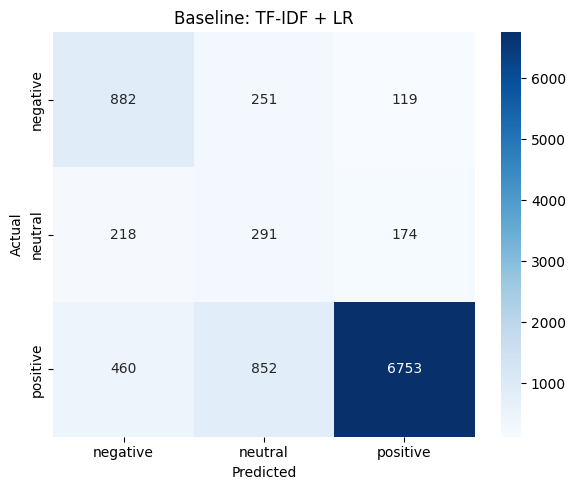

Saved to results/confusion_baseline.png


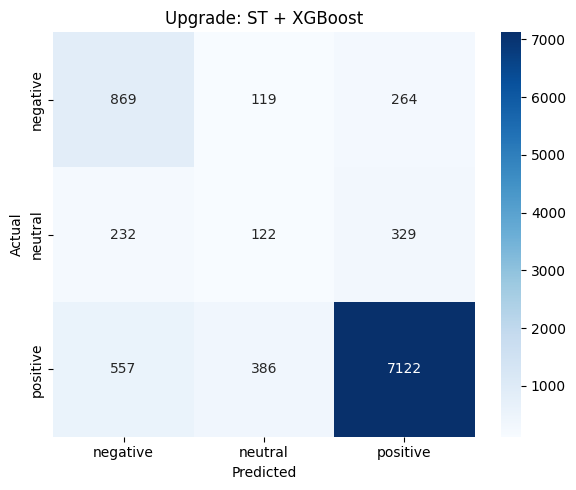

Saved to results/confusion_upgrade.png


In [14]:
def plot_confusion(y_true, y_pred, title, filename):
    labels = ['negative', 'neutral', 'positive']
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d',
                xticklabels=labels, yticklabels=labels,
                cmap='Blues')
    plt.title(title)
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.savefig(f'results/{filename}')
    plt.show()
    print(f"Saved to results/{filename}")

plot_confusion(y_test, y_pred_baseline, "Baseline: TF-IDF + LR",      "confusion_baseline.png")
plot_confusion(y_test, y_pred_labels,   "Upgrade: ST + XGBoost",       "confusion_upgrade.png")

In [ ]:
improvement = ((upgrade_f1 - baseline_f1) / baseline_f1) * 100

print("Results Summary")
print()
print(f"  {'Model':<38} {'Macro F1':>10}  Notes")
print(f"  {'-'*65}")
print(f"  {'TF-IDF + Logistic Regression':<38} {baseline_f1:>10.4f}  Baseline")
print(f"  {'ST + XGBoost (before fix)':<38} {'0.4997':>10}  No class balancing neutral F1: 0.02")
print(f"  {'ST + XGBoost (balanced, final)':<38} {upgrade_f1:>10.4f}  sample_weight=balanced")
print()
print(f"  Final improvement over baseline: {improvement:+.1f}%")

Results Summary

  Model                                    Macro F1  Notes
  -----------------------------------------------------------------
  TF-IDF + Logistic Regression               0.6004  Baseline
  ST + XGBoost (before fix)                  0.4997  No class balancing neutral F1: 0.02
  ST + XGBoost (balanced, final)             0.5621  sample_weight=balanced

  Final improvement over baseline: -6.4%
